## WORKSHOP 2- Object detection using web camera
## NAME:  OVIYA N
## REG.NO:  212223040140

In [6]:
!curl -L -o yolov4-tiny.weights https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v4_pre/yolov4-tiny.weights
!curl -L -o yolov4-tiny.cfg https://raw.githubusercontent.com/AlexeyAB/darknet/master/cfg/yolov4-tiny.cfg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  1 23.1M    1  430k    0     0   267k      0  0:01:28  0:00:01  0:01:27  267k
  6 23.1M    6 1630k    0     0   612k      0  0:00:38  0:00:02  0:00:36 1137k
 23 23.1M   23 5677k    0     0  1573k      0  0:00:15  0:00:03  0:00:12 2623k
 35 23.1M   35 8493k    0     0  1801k      0  0:00:13  0:00:04  0:00:09 2595k
 46 23.1M   46 10.7M    0     0  1964k      0  0:00:12  0:00:05  0:00:07 2646k
 59 23.1M   59 13.8M    0     0  2142k      0  0:00:11  0:00:06  0:00:05 2744k
 70 23.1M   70 16.2M    0     0  2187k      0  0:00:10  0:00:07  0:00:03 3034k
 84 23.1M   84 19.5M    0     0  2301k      0  0:0

Loading YOLOv4 model...


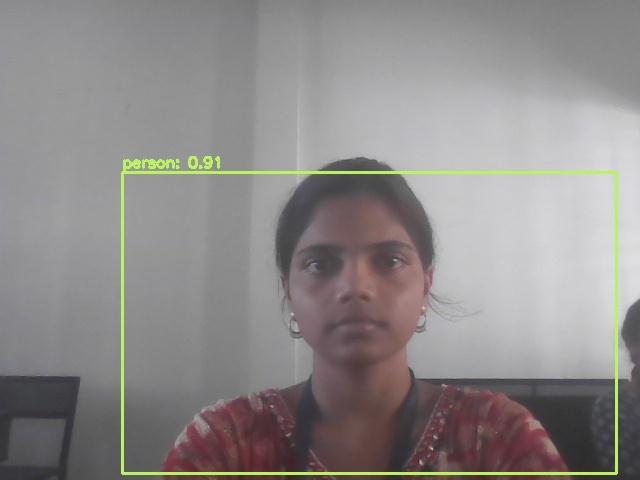


Stream stopped manually by user.
Webcam successfully released.


In [9]:
import cv2
import numpy as np
import IPython.display as display
from PIL import Image
import io

# 1. Load COCO Class Names
with open("coco.names", "r") as f:
    classes = [line.strip() for line in f.readlines()]

np.random.seed(42)
colors = np.random.uniform(0, 255, size=(len(classes), 3))

# 2. Load the Pre-trained YOLOv4 Network
print("Loading YOLOv4 model...")
# Change this line in your script:
net = cv2.dnn.readNetFromDarknet("yolov4-tiny.cfg", "yolov4-tiny.weights")
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# 3. Initialize Webcam Stream
cap = cv2.VideoCapture(0)

# Create a display handle so we can refresh the same image frame dynamically
display_handle = display.display("", display_id=True)

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab camera frame.")
            break

        height, width, _ = frame.shape

        # 4. Preprocessing Frame for YOLO (416x416)
        blob = cv2.dnn.blobFromImage(frame, 1/255.0, (416, 416), swapRB=True, crop=False)
        net.setInput(blob)
        outs = net.forward(output_layers)

        class_ids = []
        confidences = []
        boxes = []

        # 5. Parse Predictions
        for out in outs:
            for detection in out:
                scores = detection[5:]
                class_id = np.argmax(scores)
                confidence = scores[class_id]

                if confidence > 0.5:
                    center_x = int(detection[0] * width)
                    center_y = int(detection[1] * height)
                    w = int(detection[2] * width)
                    h = int(detection[3] * height)

                    x = int(center_x - w / 2)
                    y = int(center_y - h / 2)

                    boxes.append([x, y, w, h])
                    confidences.append(float(confidence))
                    class_ids.append(class_id)

        # 6. Apply Non-Maximum Suppression
        indices = cv2.dnn.NMSBoxes(boxes, confidences, score_threshold=0.5, nms_threshold=0.4)

        # 7. Annotate Frame
        if len(indices) > 0:
            for i in indices.flatten():
                x, y, w, h = boxes[i]
                label = str(classes[class_ids[i]])
                confidence_score = confidences[i]
                color = colors[class_ids[i]]

                cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
                text = f"{label}: {confidence_score:.2f}"
                cv2.putText(frame, text, (x, y - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # 8. Convert the processed frame to JPEG and update the Jupyter cell output
        _, encoded_img = cv2.imencode('.jpg', frame)
        img_bytes = io.BytesIO(encoded_img.tobytes())
        
        # Update the live notebook frame display
        display_handle.update(display.Image(data=img_bytes.read(), format='jpeg'))

except KeyboardInterrupt:
    print("\nStream stopped manually by user.")

finally:
    # Always release resources to prevent locking up your webcam
    cap.release()
    print("Webcam successfully released.")